# Phase 0: Environment Bootstrap

This notebook validates the local `uv` + Jupyter setup, records reproducible environment details, and saves the first report artifacts for later reuse.

The goal is to keep every step small, observable, and reproducible before any modeling work starts.

In [5]:
from pathlib import Path

import importlib.metadata as metadata

import json

import platform

import sys



project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

packages = ["numpy", "pandas", "matplotlib", "seaborn", "jupyterlab", "ipykernel"]



def package_version(name: str) -> str:

    try:

        return metadata.version(name)

    except metadata.PackageNotFoundError:

        return "not installed"



environment = {

    "python": sys.version.split()[0],

    "executable": sys.executable,

    "platform": platform.platform(),

    "machine": platform.machine(),

    "working_directory": str(Path.cwd()),

    "project_root": str(project_root),

    "packages": {name: package_version(name) for name in packages},

}



print(json.dumps(environment, indent=2))


{
  "python": "3.10.20",
  "executable": "/home/selba/Desktop/ENSIAS/Mlops/PFA/code/.venv/bin/python",
  "platform": "Linux-7.0.10-1-cachyos-x86_64-with-glibc2.43",
  "machine": "x86_64",
  "working_directory": "/home/selba/Desktop/ENSIAS/Mlops/PFA/code/notebooks",
  "project_root": "/home/selba/Desktop/ENSIAS/Mlops/PFA/code",
  "packages": {
    "numpy": "1.26.4",
    "pandas": "2.3.3",
    "matplotlib": "3.10.9",
    "seaborn": "0.13.2",
    "jupyterlab": "4.5.7",
    "ipykernel": "6.31.0"
  }
}


Saved figure to /home/selba/Desktop/ENSIAS/Mlops/PFA/code/reports/figures/phase0_bootstrap_check.png


,checkpoint,order
0,Bootstrap,1
1,Dependencies,2
2,Notebook,3


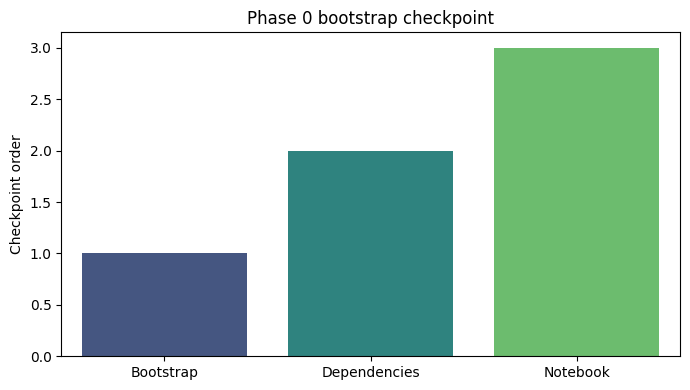

In [6]:
import pandas as pd

import matplotlib.pyplot as plt

import seaborn as sns



artifact_dir = project_root / "reports" / "artifacts"

figure_dir = project_root / "reports" / "figures"

artifact_dir.mkdir(parents=True, exist_ok=True)

figure_dir.mkdir(parents=True, exist_ok=True)



timeline = pd.DataFrame({

    "checkpoint": ["Bootstrap", "Dependencies", "Notebook"],

    "order": [1, 2, 3],

})



fig, ax = plt.subplots(figsize=(7, 4))

sns.barplot(data=timeline, x="checkpoint", y="order", hue="checkpoint", ax=ax, palette="viridis", legend=False)

ax.set_title("Phase 0 bootstrap checkpoint")

ax.set_xlabel("")

ax.set_ylabel("Checkpoint order")

fig.tight_layout()



figure_path = figure_dir / "phase0_bootstrap_check.png"

fig.savefig(figure_path, dpi=160, bbox_inches="tight")

print(f"Saved figure to {figure_path}")

timeline


In [7]:
summary_path = artifact_dir / "environment_summary.json"
summary_path.write_text(json.dumps(environment, indent=2), encoding="utf-8")
print(f"Saved environment summary to {summary_path}")

Saved environment summary to /home/selba/Desktop/ENSIAS/Mlops/PFA/code/reports/artifacts/environment_summary.json
